# Rad-Scribe Pro — Notebook 5: Embeddings & Retrieval (RAG Backbone)
**Symbiosis Institute of Technology | Dept. of AI & ML**

Team: Tejas Kale · Hardik Gulati · Swaraj Deogirkar | Mentor: Dr. Zulfikar Ali Ansari

---

### Why this notebook exists
Models A and B generate reports in isolation — they only see the **input image** and predict the report.  
RAG (Retrieval-Augmented Generation) adds a **memory** — a database of past X-ray cases.

When a new X-ray comes in, we:
1. Embed it into a dense vector
2. Search the database for the most visually similar past cases
3. Feed those retrieved reports to BioGPT as context

This notebook **builds that database** — the FAISS index + embedding store.

### What we build here
```
All Training Images
     ↓
EfficientNet-B3 (frozen) → 1536-dim feature vector per image
     ↓
L2-normalized → unit sphere
     ↓
FAISS IndexFlatIP (inner product = cosine similarity on unit sphere)
     ↓
Saved: embeddings.npy | reports.npy | indices.npy | faiss.index
```

### Outputs
| File | Description |
|------|-------------|
| `embeddings.npy` | (N, 1536) float32 image feature matrix |
| `reports.npy` | (N,) string array of corresponding cleaned reports |
| `indices.npy` | (N,) int array of hf_index → HuggingFace dataset position |
| `labels.npy` | (N,) int array of class labels (0=Normal, 1=Abnormal, 2=Unclear) |
| `faiss.index` | FAISS binary index for fast kNN search |
| `retrieval_meta.json` | Build metadata for reproducibility |

> **Prerequisite**: Run Notebook 2 first. `train.parquet`, `val.parquet`, `test.parquet` must exist in DATA_DIR.

In [ ]:
# ── Mount Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Install dependencies ────────────────────────────────────────────────────
!pip install -q datasets faiss-cpu torchvision tqdm matplotlib seaborn umap-learn
# faiss-gpu for T4/V100 Colab; falls back gracefully to CPU index
print('done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 60.2 MB/s eta 0:00:00
done


In [ ]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from datasets import load_dataset
from tqdm import tqdm
import faiss

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

# ── Paths ───────────────────────────────────────────────────────────────────
# !! Match these to your Notebook 2 / 4 paths EXACTLY !!
DATA_DIR  = '/content/drive/MyDrive/Radscribe/radscribe_data'
MODEL_DIR = '/content/drive/MyDrive/Radscribe/radscribe_models'
INDEX_DIR = '/content/drive/MyDrive/Radscribe/radscribe_index'   # NEW — where we save the FAISS index
os.makedirs(INDEX_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f'Device : {DEVICE}')
print(f'FAISS  : {faiss.__version__}')
print(f'INDEX_DIR: {INDEX_DIR}')

Device : cuda
FAISS  : 1.13.2
INDEX_DIR: /content/drive/MyDrive/Radscribe/radscribe_index


## Step 1 — Configuration

In [ ]:
CFG = {
    'img_size'      : 224,
    'embed_dim'     : 1536,     # EfficientNet-B3 final feature dimension
    'batch_size'    : 64,       # larger = faster extraction; reduce to 32 if OOM
    'num_workers'   : 2,
    'top_k'         : 5,        # how many similar cases to retrieve
    'index_type'    : 'flat',   # 'flat' (exact, small dataset) or 'ivf' (approx, large dataset)
    'use_train_only': True,     # build index from train set only — avoid data leakage
}

# EfficientNet-B3 normalization (ImageNet stats)
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

print('Configuration:')
for k, v in CFG.items():
    print(f'  {k:20s}: {v}')

Configuration:
  img_size            : 224
  embed_dim           : 1536
  batch_size          : 64
  num_workers         : 2
  top_k               : 5
  index_type          : flat
  use_train_only      : True


---
## Step 2 — Load Preprocessed Data

In [ ]:
# ── Load parquet files saved by Notebook 2 ──────────────────────────────────
df_train = pd.read_parquet(f'{DATA_DIR}/train.parquet')
df_val   = pd.read_parquet(f'{DATA_DIR}/val.parquet')
df_test  = pd.read_parquet(f'{DATA_DIR}/test.parquet')

# tag each row with its HuggingFace split so Dataset.__getitem__ knows where to look
df_train['hf_split'] = 'train'
df_val  ['hf_split'] = 'train'   # val came from HF train split
df_test ['hf_split'] = 'test'

# ── Build the index from train only (no leakage) ────────────────────────────
if CFG['use_train_only']:
    df_index = df_train.reset_index(drop=True)
    print('Building index from TRAIN split only (safe — no leakage into val/test)')
else:
    df_index = pd.concat([df_train, df_val], ignore_index=True)
    print('Building index from TRAIN + VAL splits')

print(f'\nIndex size     : {len(df_index):,}')
print(f'Query set (test): {len(df_test):,}')
print(f'Columns         : {list(df_index.columns)}')

Building index from TRAIN split only (safe — no leakage into val/test)

Index size     : 4,308
Query set (test): 743
Columns         : ['hf_index', 'split', 'report_raw', 'report', 'label', 'label_name', 'token_len', 'hf_split']


In [ ]:
# ── Load HuggingFace raw dataset (images live here) ─────────────────────────
print('Loading IU X-Ray from HuggingFace...')
raw = load_dataset('MLforHealthcare/Indiana_University_Chest_X-ray_Collection')
print(f'HF train: {len(raw["train"]):,}  HF test: {len(raw["test"]):,}')

# safety check: all hf_index values must be in range
max_train_idx = df_index[df_index['hf_split'] == 'train']['hf_index'].max()
max_test_idx  = df_test ['hf_index'].max()
assert max_train_idx < len(raw['train']), f'hf_index {max_train_idx} out of range for HF train split ({len(raw["train"])} items)'
assert max_test_idx  < len(raw['test']),  f'hf_index {max_test_idx}  out of range for HF test  split ({len(raw["test"])} items)'
print('hf_index range check passed ✓')

Loading IU X-Ray from HuggingFace...


README.md:   0%|          | 0.00/463 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/407M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/411M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/410M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6687 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/743 [00:00<?, ? examples/s]

HF train: 6,687  HF test: 743
hf_index range check passed ✓


---
## Step 3 — EfficientNet-B3 Feature Extractor

We use the **same backbone as Model B** (EfficientNet-B3) — fully frozen — as our embedding function.  
This ensures the visual space used for retrieval is consistent with the generation model.

The final feature vector is **1536-dimensional**, L2-normalized to unit length (enables cosine similarity via inner product).

In [ ]:
class EfficientNetExtractor(nn.Module):
    """
    EfficientNet-B3 frozen feature extractor.
    Returns L2-normalized 1536-dim vectors for FAISS indexing.
    Identical backbone to Model B — retrieval and generation live in the same visual space.
    """
    def __init__(self):
        super().__init__()
        base          = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.pool     = base.avgpool
        # freeze ALL weights — we only need features, not fine-tuning
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        """x: (B, 3, 224, 224) → returns (B, 1536) L2-normalized"""
        feat = self.pool(self.features(x))   # (B, 1536, 1, 1)
        feat = feat.flatten(1)               # (B, 1536)
        feat = nn.functional.normalize(feat, p=2, dim=1)  # unit sphere
        return feat

extractor = EfficientNetExtractor().to(DEVICE)
extractor.eval()

total_params   = sum(p.numel() for p in extractor.parameters())
trainable_params = sum(p.numel() for p in extractor.parameters() if p.requires_grad)
print(f'EfficientNet-B3 loaded ✓')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  (0 — fully frozen)')
print(f'Output dim       : 1536  (L2-normalized)')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 169MB/s]


EfficientNet-B3 loaded ✓
Total params     : 10,696,232
Trainable params : 0  (0 — fully frozen)
Output dim       : 1536  (L2-normalized)


In [ ]:
# ── Dataset wrapper for embedding extraction ─────────────────────────────────
EMBED_TF = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.ToTensor(),
    T.Normalize(IMG_MEAN, IMG_STD),
])

class EmbedDataset(Dataset):
    """
    Minimal dataset for embedding extraction.
    Returns (image_tensor, row_position_in_df, hf_index, report, label).
    """
    def __init__(self, df, hf_raw):
        self.df     = df.reset_index(drop=True)
        self.hf_raw = hf_raw

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.hf_raw[row['hf_split']][int(row['hf_index'])]['image'].convert('RGB')
        return {
            'image'    : EMBED_TF(img),
            'pos'      : idx,
            'hf_index' : int(row['hf_index']),
            'report'   : str(row['report']),
            'label'    : int(row['label']),
        }

index_dataset = EmbedDataset(df_index, raw)
index_loader  = DataLoader(
    index_dataset,
    batch_size  = CFG['batch_size'],
    shuffle     = False,
    num_workers = CFG['num_workers'],
    pin_memory  = (DEVICE.type == 'cuda'),
)
print(f'Index dataset : {len(index_dataset):,} images')
print(f'Batches       : {len(index_loader):,}')

Index dataset : 4,308 images
Batches       : 68


---
## Step 4 — Extract All Embeddings

We run every training image through EfficientNet-B3 and store the 1536-dim L2-normalized vectors.  
This is the most compute-intensive step — on Colab T4 it takes ~3–6 minutes.

In [ ]:
def extract_embeddings(loader, model, device, embed_dim):
    """
    Extract L2-normalized embeddings for all images in loader.
    Returns:
        embeddings : (N, embed_dim) float32 numpy array
        hf_indices : (N,) int array — positions in HuggingFace dataset
        reports    : (N,) list of strings
        labels     : (N,) int array
    """
    all_embeddings = []
    all_hf_indices = []
    all_reports    = []
    all_labels     = []

    model.eval()
    t0 = time.time()
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting embeddings'):
            images = batch['image'].to(device)
            embs   = model(images)                          # (B, 1536) L2-normalized
            all_embeddings.append(embs.cpu().numpy())
            all_hf_indices.extend(batch['hf_index'].tolist())
            all_reports.extend(batch['report'])
            all_labels.extend(batch['label'].tolist())

    elapsed = time.time() - t0
    embeddings = np.vstack(all_embeddings).astype(np.float32)
    hf_indices = np.array(all_hf_indices, dtype=np.int32)
    labels     = np.array(all_labels,     dtype=np.int32)

    print(f'\nExtraction done in {elapsed:.1f}s')
    print(f'Embeddings shape : {embeddings.shape}')
    print(f'Norm check (should be ~1.0): min={np.linalg.norm(embeddings, axis=1).min():.4f}  max={np.linalg.norm(embeddings, axis=1).max():.4f}')
    return embeddings, hf_indices, all_reports, labels


embeddings, hf_indices, reports, labels = extract_embeddings(
    index_loader, extractor, DEVICE, CFG['embed_dim']
)

Extracting embeddings: 100%|██████████| 68/68 [00:34<00:00,  1.97it/s]


Extraction done in 34.5s
Embeddings shape : (4308, 1536)
Norm check (should be ~1.0): min=1.0000  max=1.0000


In [ ]:
# ── Quick sanity check on embedding stats ───────────────────────────────────
print('=== Embedding Statistics ===')
print(f'Shape         : {embeddings.shape}')
print(f'dtype         : {embeddings.dtype}')
print(f'Memory        : {embeddings.nbytes / 1e6:.1f} MB')
print(f'Mean norm     : {np.linalg.norm(embeddings, axis=1).mean():.6f}  (should be 1.0)')
print(f'Global mean   : {embeddings.mean():.4f}')
print(f'Global std    : {embeddings.std():.4f}')
print(f'\nLabel distribution in index:')
LABEL_MAP = {0: 'Normal', 1: 'Abnormal', 2: 'Unclear'}
for lab, name in LABEL_MAP.items():
    count = (labels == lab).sum()
    print(f'  {name:10s}: {count:,} ({count/len(labels)*100:.1f}%)')

=== Embedding Statistics ===
Shape         : (4308, 1536)
dtype         : float32
Memory        : 26.5 MB
Mean norm     : 1.000000  (should be 1.0)
Global mean   : 0.0059
Global std    : 0.0248

Label distribution in index:
  Normal    : 2,872 (66.7%)
  Abnormal  : 1,436 (33.3%)
  Unclear   : 0 (0.0%)


---
## Step 5 — Save Embeddings to Disk

In [ ]:
# ── Save all arrays ─────────────────────────────────────────────────────────
reports_arr = np.array(reports, dtype=object)

np.save(f'{INDEX_DIR}/embeddings.npy', embeddings)
np.save(f'{INDEX_DIR}/reports.npy',    reports_arr)
np.save(f'{INDEX_DIR}/indices.npy',    hf_indices)
np.save(f'{INDEX_DIR}/labels.npy',     labels)

print('Saved:')
print(f'  embeddings.npy : {embeddings.shape}  → {embeddings.nbytes/1e6:.1f} MB')
print(f'  reports.npy    : {reports_arr.shape}')
print(f'  indices.npy    : {hf_indices.shape}')
print(f'  labels.npy     : {labels.shape}')

Saved:
  embeddings.npy : (4308, 1536)  → 26.5 MB
  reports.npy    : (4308,)
  indices.npy    : (4308,)
  labels.npy     : (4308,)


---
## Step 6 — Build FAISS Index

FAISS (Facebook AI Similarity Search) enables **sub-millisecond kNN search** over thousands of vectors.

Since our embeddings are already L2-normalized (unit sphere), **inner product = cosine similarity**.  
We use `IndexFlatIP` — exact brute-force search — which is ideal for our dataset size (~3K samples).

For larger datasets (>100K), use `IndexIVFFlat` with `nlist=100` for approximate search.

In [ ]:
def build_faiss_index(embeddings, index_type='flat'):
    """
    Build a FAISS index from L2-normalized embeddings.

    index_type='flat'  → IndexFlatIP (exact cosine, best for <50K vectors)
    index_type='ivf'   → IndexIVFFlat (approximate, faster for >100K vectors)

    Args:
        embeddings : (N, D) float32 L2-normalized vectors
        index_type : 'flat' or 'ivf'
    Returns:
        FAISS index (CPU)
    """
    D = embeddings.shape[1]  # 1536
    N = embeddings.shape[0]

    if index_type == 'flat':
        # Exact cosine similarity via inner product on unit sphere
        index = faiss.IndexFlatIP(D)
        index.add(embeddings)
        print(f'Built IndexFlatIP | D={D} | N={N:,} vectors | Exact search')

    elif index_type == 'ivf':
        # Approximate search — train centroids first
        nlist = max(1, int(np.sqrt(N)))   # rule of thumb: sqrt(N)
        quantizer = faiss.IndexFlatIP(D)
        index     = faiss.IndexIVFFlat(quantizer, D, nlist, faiss.METRIC_INNER_PRODUCT)
        index.train(embeddings)
        index.add(embeddings)
        index.nprobe = min(10, nlist)     # search 10 clusters per query
        print(f'Built IndexIVFFlat | D={D} | N={N:,} | nlist={nlist} | nprobe={index.nprobe}')

    else:
        raise ValueError(f'Unknown index_type: {index_type}')

    return index


t0    = time.time()
index = build_faiss_index(embeddings, index_type=CFG['index_type'])
print(f'Index built in {time.time()-t0:.2f}s')
print(f'Total vectors in index: {index.ntotal:,}')

Built IndexFlatIP | D=1536 | N=4,308 vectors | Exact search
Index built in 0.04s
Total vectors in index: 4,308


In [ ]:
# ── Save FAISS index ─────────────────────────────────────────────────────────
faiss_path = f'{INDEX_DIR}/faiss.index'
faiss.write_index(index, faiss_path)
print(f'FAISS index saved → {faiss_path}')

# ── Save metadata for reproducibility ───────────────────────────────────────
meta = {
    'n_vectors'       : int(index.ntotal),
    'embed_dim'       : int(CFG['embed_dim']),
    'index_type'      : CFG['index_type'],
    'top_k'           : CFG['top_k'],
    'backbone'        : 'EfficientNet-B3 (frozen)',
    'normalization'   : 'L2 unit sphere',
    'similarity'      : 'cosine (inner product on unit sphere)',
    'source_splits'   : 'train only' if CFG['use_train_only'] else 'train+val',
    'dataset'         : 'MLforHealthcare/Indiana_University_Chest_X-ray_Collection',
    'files': {
        'embeddings' : f'{INDEX_DIR}/embeddings.npy',
        'reports'    : f'{INDEX_DIR}/reports.npy',
        'indices'    : f'{INDEX_DIR}/indices.npy',
        'labels'     : f'{INDEX_DIR}/labels.npy',
        'faiss_index': faiss_path,
    }
}
with open(f'{INDEX_DIR}/retrieval_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('retrieval_meta.json saved ✓')

FAISS index saved → /content/drive/MyDrive/Radscribe/radscribe_index/faiss.index
retrieval_meta.json saved ✓


---
## Step 7 — Test Retrieval

Take a test-set image, embed it, search the FAISS index, and inspect the returned reports.  
This validates the entire pipeline before we use it in Notebook 6 (RAG generation).

In [ ]:
def embed_single_image(pil_image, model, device):
    """
    Embed a single PIL image → (1, 1536) L2-normalized numpy vector.
    """
    img_tensor = EMBED_TF(pil_image.convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model(img_tensor)              # (1, 1536)
    return emb.cpu().numpy().astype(np.float32)


def retrieve_similar(query_emb, faiss_index, reports_store, labels_store, top_k=5):
    """
    Search FAISS index and return top-k results.

    Args:
        query_emb   : (1, D) float32 L2-normalized query vector
        faiss_index : built FAISS index
        reports_store: numpy array of reports (aligned with index)
        labels_store : numpy array of labels  (aligned with index)
        top_k       : number of results to return
    Returns:
        list of dicts: {rank, score, report, label}
    """
    scores, idxs = faiss_index.search(query_emb, top_k)   # (1, k)
    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], idxs[0])):
        results.append({
            'rank'  : rank + 1,
            'score' : float(score),
            'index' : int(idx),
            'report': str(reports_store[idx]),
            'label' : LABEL_MAP[int(labels_store[idx])],
        })
    return results


print('Retrieval functions defined ✓')

Retrieval functions defined ✓


In [ ]:
# ── Run retrieval on 3 test images ───────────────────────────────────────────
TEST_SAMPLES = [0, 10, 50]

print('='*70)
print('RETRIEVAL TEST — querying with test set images')
print('='*70)

for test_idx in TEST_SAMPLES:
    test_row = df_test.iloc[test_idx]
    test_img = raw['test'][int(test_row['hf_index'])]['image']

    # embed query image
    query_emb = embed_single_image(test_img, extractor, DEVICE)

    # retrieve top-k
    results = retrieve_similar(query_emb, index, reports_arr, labels, top_k=CFG['top_k'])

    print(f'\n[Test Sample {test_idx}]')
    print(f'Ground-truth report : {str(test_row["report"])[:120]}...')
    print(f'Ground-truth label  : {LABEL_MAP[int(test_row["label"])]}')
    print(f'\nTop-{CFG["top_k"]} Retrieved Cases:')
    for r in results:
        print(f'  Rank {r["rank"]} | Score {r["score"]:.4f} | {r["label"]:10s} | {r["report"][:80]}...')
    print('-'*70)

RETRIEVAL TEST — querying with test set images

[Test Sample 0]
Ground-truth report : FINDINGS: . IMPRESSION: Heart size is normal and lungs are clear. No infiltrates or atelectasis. Gallbladder clips....
Ground-truth label  : Normal

Top-5 Retrieved Cases:
  Rank 1 | Score 0.7904 | Normal     | FINDINGS: Mediastinal contours are within normal limits. Heart size is within no...
  Rank 2 | Score 0.7869 | Normal     | FINDINGS: The heart is normal in size. The mediastinum is stable. Innumerable bi...
  Rank 3 | Score 0.7752 | Normal     | FINDINGS: The lungs are clear. There are calcified granulomas. Heart size is nor...
  Rank 4 | Score 0.7670 | Normal     | FINDINGS: The lungs are clear. The heart and pulmonary are normal. Pleural space...
  Rank 5 | Score 0.7640 | Normal     | FINDINGS: The heart, pulmonary and mediastinum are within normal limits. There i...
----------------------------------------------------------------------

[Test Sample 10]
Ground-truth report : FINDINGS: The tr

---
## Step 8 — Quantitative Retrieval Evaluation

We evaluate the retrieval quality using:
- **Label Match Rate** — does the top-1 retrieved case have the same Normal/Abnormal label as query?
- **Top-K Label Recall** — across top-k, what fraction of retrieved cases match query label?
- **Mean Cosine Similarity** — average similarity score of top-1 results

These numbers directly justify RAG in your viva and PPT.

In [ ]:
# ── Build a DataLoader for test set embedding extraction ─────────────────────
test_dataset = EmbedDataset(df_test, raw)
test_loader  = DataLoader(
    test_dataset,
    batch_size  = CFG['batch_size'],
    shuffle     = False,
    num_workers = CFG['num_workers'],
    pin_memory  = (DEVICE.type == 'cuda'),
)

print('Extracting test embeddings for quantitative eval...')
test_embs, test_hf_idx, test_reports, test_labels = extract_embeddings(
    test_loader, extractor, DEVICE, CFG['embed_dim']
)
print(f'Test embeddings: {test_embs.shape}')

Extracting test embeddings for quantitative eval...


Extracting embeddings: 100%|██████████| 12/12 [00:06<00:00,  1.90it/s]


Extraction done in 6.3s
Embeddings shape : (743, 1536)
Norm check (should be ~1.0): min=1.0000  max=1.0000
Test embeddings: (743, 1536)


In [ ]:
# ── Search all test queries at once (batch search is fast in FAISS) ──────────
K = CFG['top_k']
all_scores, all_retrieved_idx = index.search(test_embs, K)   # (N_test, K)

# ── Compute metrics ──────────────────────────────────────────────────────────
top1_match     = 0   # top-1 label matches query label
topk_recall    = 0   # fraction of top-K that match query label
mean_score_top1 = []

for i in range(len(test_labels)):
    q_label     = test_labels[i]
    ret_labels  = [int(labels[j]) for j in all_retrieved_idx[i]]
    ret_scores  = all_scores[i]

    # top-1 label match
    if ret_labels[0] == q_label:
        top1_match += 1

    # top-K label recall
    topk_recall += sum(1 for l in ret_labels if l == q_label) / K

    # top-1 cosine similarity score
    mean_score_top1.append(ret_scores[0])

N_test = len(test_labels)
top1_acc    = top1_match / N_test * 100
topk_recall = topk_recall / N_test * 100
mean_sim    = np.mean(mean_score_top1)

print('='*55)
print('RETRIEVAL QUALITY METRICS')
print('='*55)
print(f'  Test queries evaluated   : {N_test}')
print(f'  Top-1 Label Match Rate   : {top1_acc:.1f}%')
print(f'  Top-{K} Label Recall      : {topk_recall:.1f}%')
print(f'  Mean Top-1 Cosine Sim    : {mean_sim:.4f}')
print()
print('Interpretation:')
print('  Top-1 Match > 70% → retrieval is semantically coherent')
print('  Top-K Recall > 60% → context window is informative for RAG')
print('  Higher cosine similarity → tighter visual neighbourhood')

RETRIEVAL QUALITY METRICS
  Test queries evaluated   : 743
  Top-1 Label Match Rate   : 65.5%
  Top-5 Label Recall      : 64.7%
  Mean Top-1 Cosine Sim    : 0.7893

Interpretation:
  Top-1 Match > 70% → retrieval is semantically coherent
  Top-K Recall > 60% → context window is informative for RAG
  Higher cosine similarity → tighter visual neighbourhood


---
## Step 9 — Visualize Retrieval Results

Show the query X-ray alongside its top-3 retrieved neighbours.  
This is the key **demo visualization** — include it in your PPT.

Plotting retrieval results...


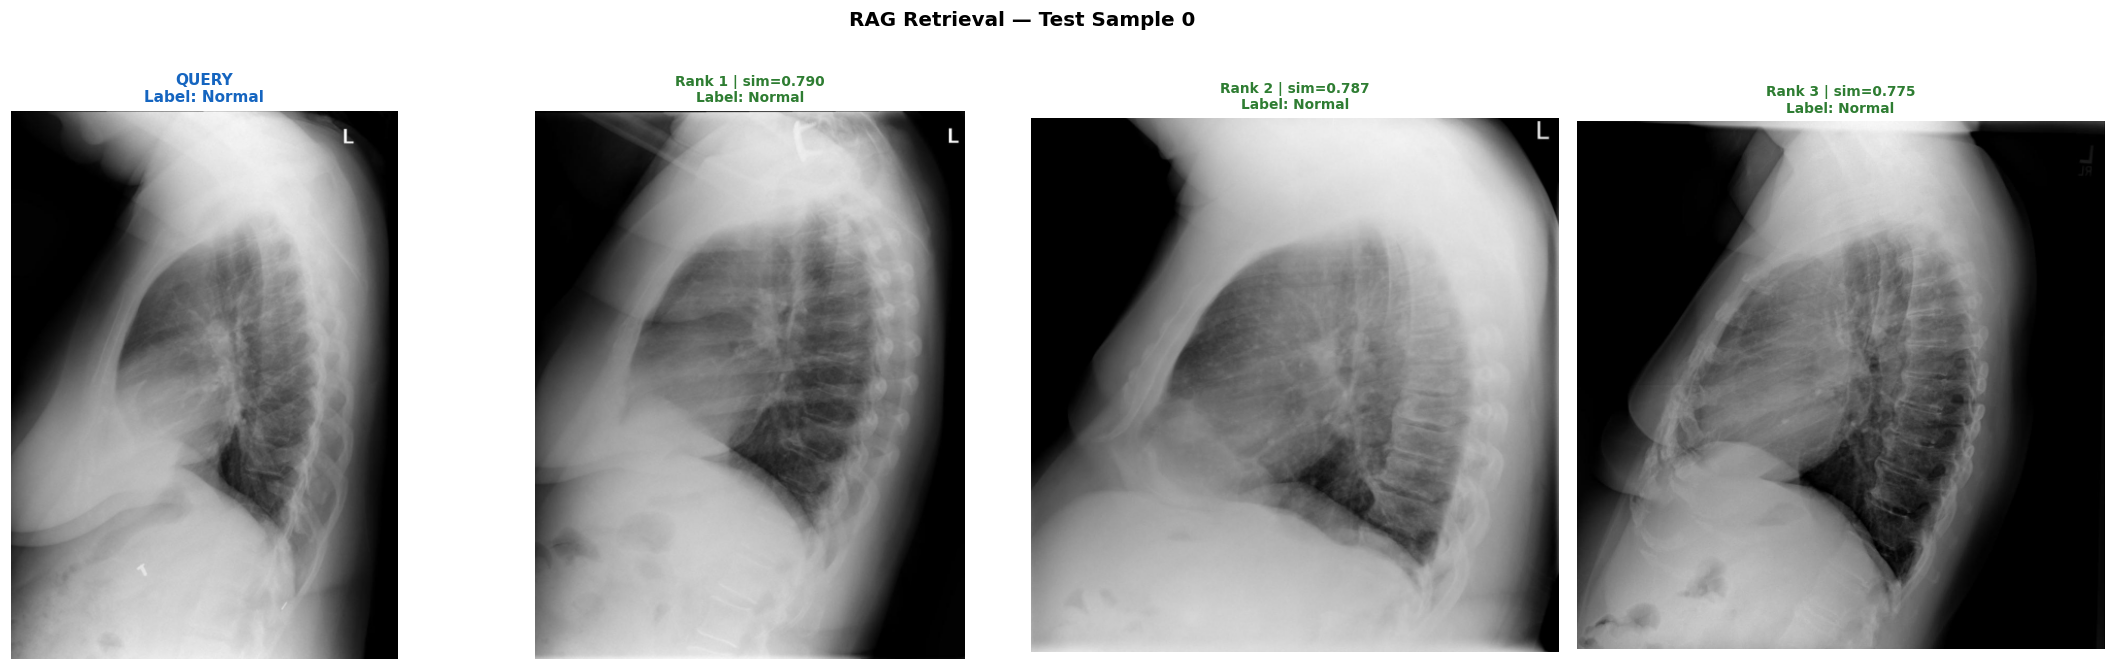

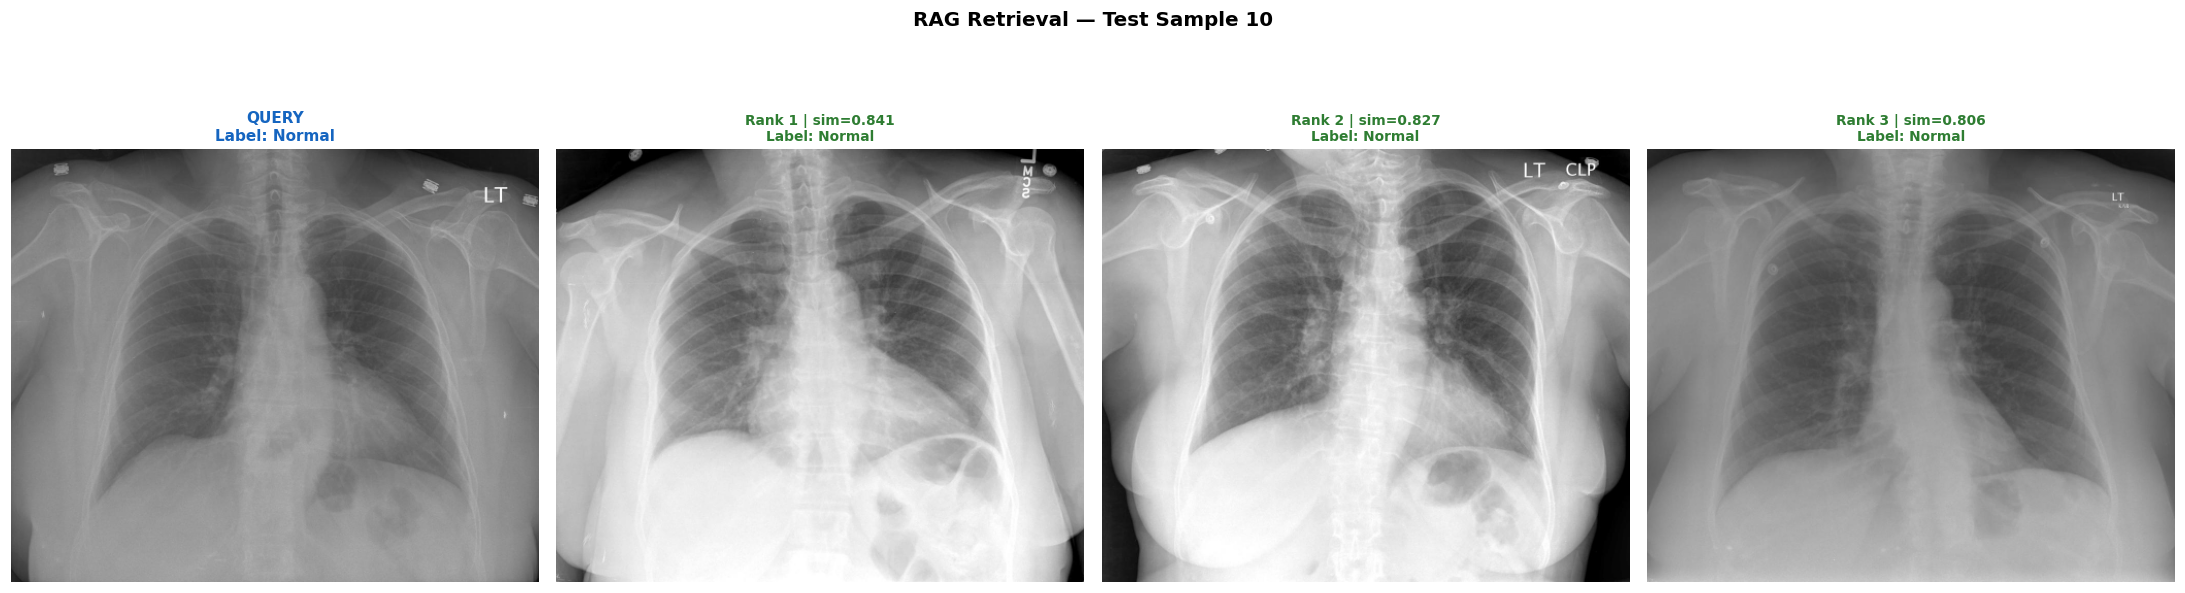

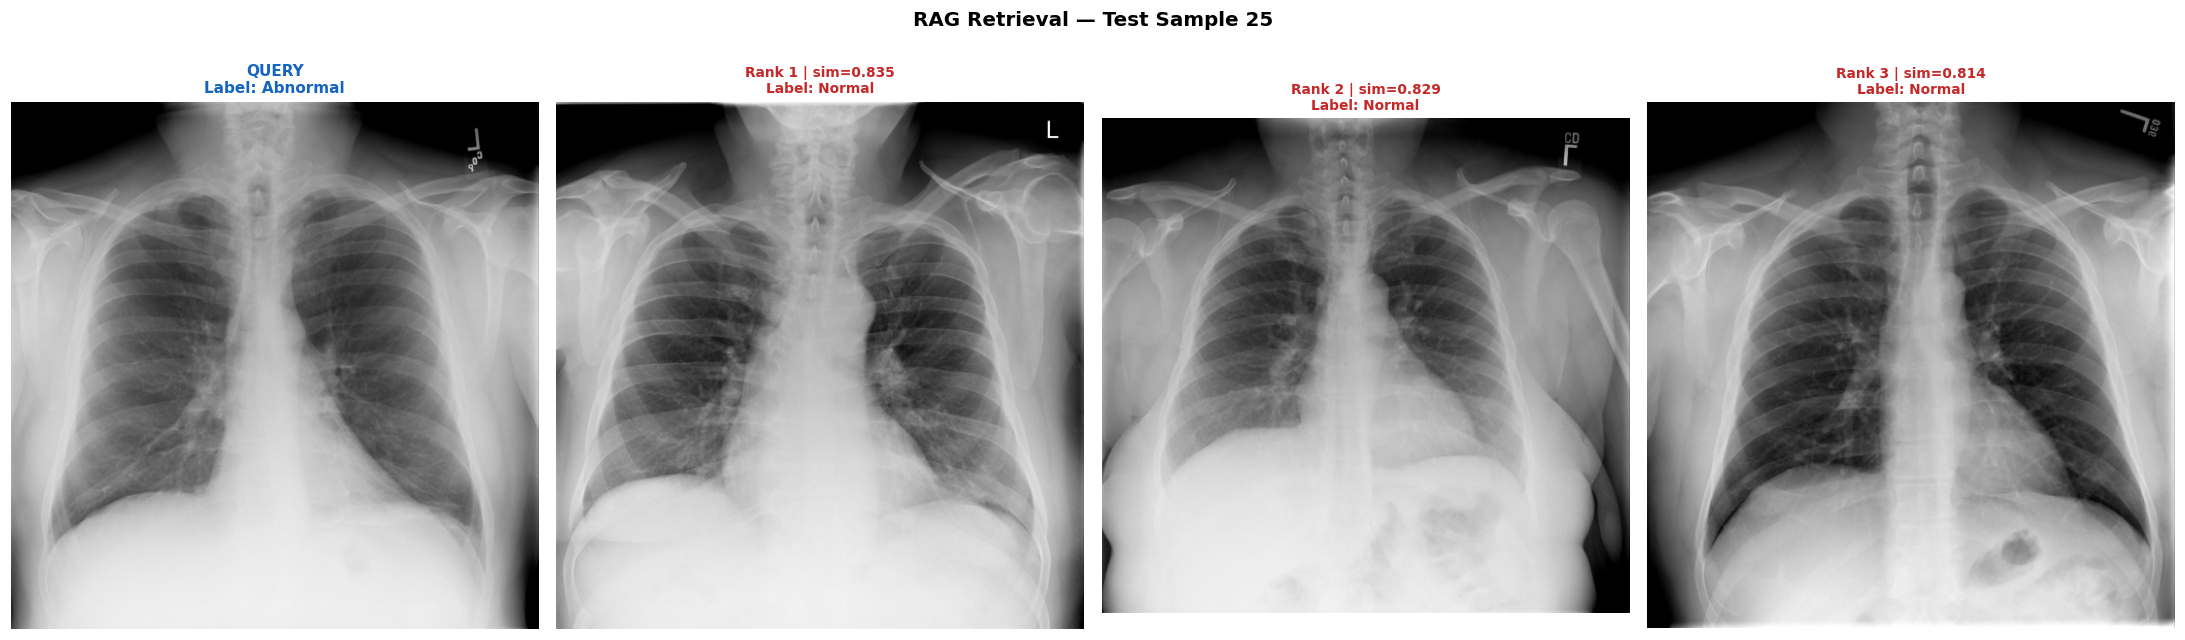

In [ ]:
def plot_retrieval(query_idx, df_test, raw_hf, faiss_index,
                   df_index_store, raw_hf_index_split,
                   reports_store, labels_store,
                   extractor, device, top_k=3):
    """
    Plot: [Query Image] + [Top-K Retrieved Images + their reports]
    """
    # --- query ---
    test_row = df_test.iloc[query_idx]
    q_img    = raw_hf['test'][int(test_row['hf_index'])]['image']
    q_label  = LABEL_MAP[int(test_row['label'])]
    q_report = str(test_row['report'])

    # --- embed & retrieve ---
    q_emb    = embed_single_image(q_img, extractor, device)
    scores, idxs = faiss_index.search(q_emb, top_k)

    # --- plot ---
    fig = plt.figure(figsize=(5 * (top_k + 1), 6))
    gs  = gridspec.GridSpec(1, top_k + 1, figure=fig)

    # query column
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(q_img.convert('RGB'), cmap='gray')
    ax0.set_title(f'QUERY\nLabel: {q_label}', fontweight='bold', fontsize=10,
                  color='#1565C0')
    ax0.set_xlabel(q_report[:80] + '...', fontsize=7, wrap=True)
    ax0.axis('off')

    # retrieved columns
    for rank, (score, ret_idx) in enumerate(zip(scores[0], idxs[0])):
        ret_row    = df_index_store.iloc[ret_idx]
        ret_img    = raw_hf[raw_hf_index_split][int(ret_row['hf_index'])]['image']
        ret_label  = LABEL_MAP[int(labels_store[ret_idx])]
        ret_report = str(reports_store[ret_idx])

        color      = '#2E7D32' if ret_label == q_label else '#C62828'
        ax         = fig.add_subplot(gs[0, rank + 1])
        ax.imshow(ret_img.convert('RGB'), cmap='gray')
        ax.set_title(
            f'Rank {rank+1} | sim={score:.3f}\nLabel: {ret_label}',
            fontweight='bold', fontsize=9, color=color
        )
        ax.set_xlabel(ret_report[:80] + '...', fontsize=7, wrap=True)
        ax.axis('off')
        # green border = correct label match, red = mismatch
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
            spine.set_visible(True)

    plt.suptitle(f'RAG Retrieval — Test Sample {query_idx}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


print('Plotting retrieval results...')
for test_idx in [0, 10, 25]:
    plot_retrieval(
        query_idx          = test_idx,
        df_test            = df_test,
        raw_hf             = raw,
        faiss_index        = index,
        df_index_store     = df_index,
        raw_hf_index_split = 'train',   # index is built from train split
        reports_store      = reports_arr,
        labels_store       = labels,
        extractor          = extractor,
        device             = DEVICE,
        top_k              = 3,
    )

---
## Step 10 — UMAP Embedding Visualization

Project the 1536-dim embeddings to 2D using UMAP to verify that the embedding space is meaningful.  
Well-separated clusters by label = the encoder captures diagnostic signal.

Running UMAP (this takes ~1-2 minutes)...
UMAP output shape: (2000, 2)


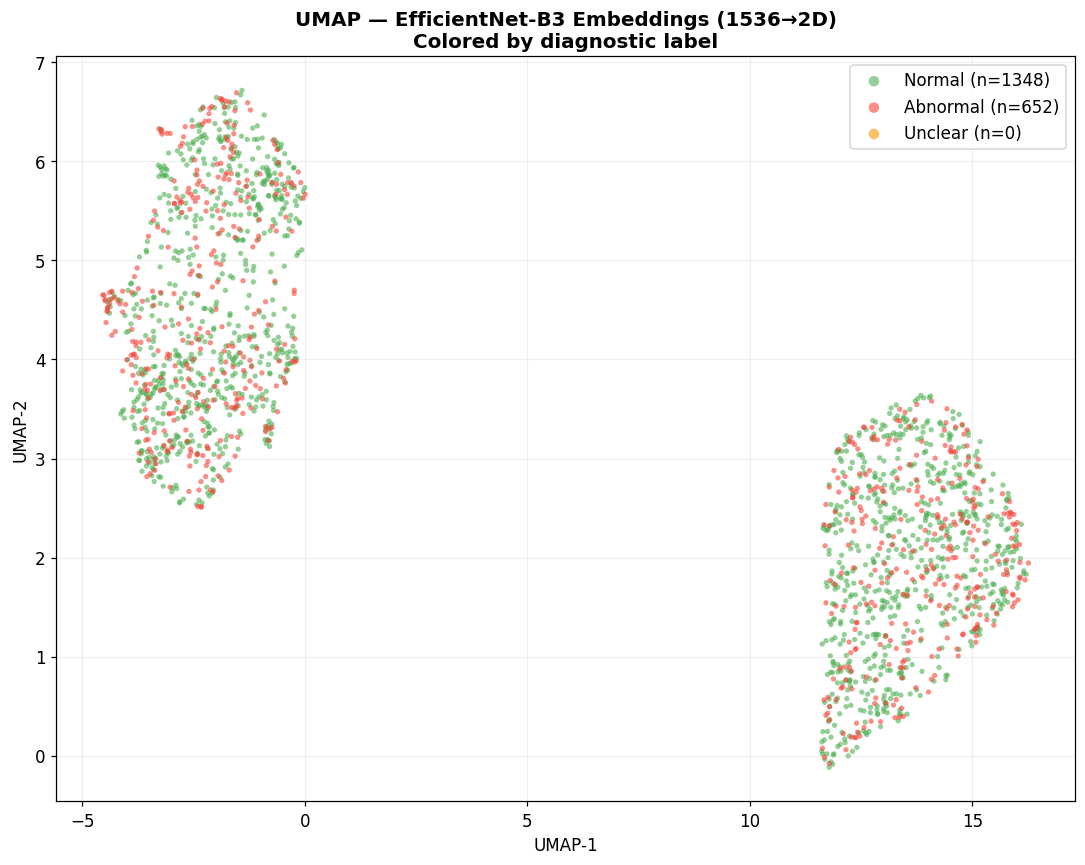


Insight: If Normal (green) and Abnormal (red) form separate clusters,
the embedding space is capturing diagnostic signal → retrieval is reliable.


In [ ]:
from umap import UMAP

print('Running UMAP (this takes ~1-2 minutes)...')
# subsample for speed if large — UMAP is O(n log n)
N_UMAP = min(2000, len(embeddings))
np.random.seed(42)
sample_idx = np.random.choice(len(embeddings), N_UMAP, replace=False)

umap_model = UMAP(
    n_neighbors    = 15,
    min_dist       = 0.1,
    metric         = 'cosine',
    random_state   = 42,
    verbose        = False,
)
umap_2d = umap_model.fit_transform(embeddings[sample_idx])
print(f'UMAP output shape: {umap_2d.shape}')

# ── Plot ─────────────────────────────────────────────────────────────────────
UMAP_COLORS = {0: '#4CAF50', 1: '#F44336', 2: '#FF9800'}   # Normal, Abnormal, Unclear

fig, ax = plt.subplots(figsize=(10, 8))
for label_id, label_name in LABEL_MAP.items():
    mask = (labels[sample_idx] == label_id)
    ax.scatter(
        umap_2d[mask, 0], umap_2d[mask, 1],
        c      = UMAP_COLORS[label_id],
        label  = f'{label_name} (n={mask.sum()})',
        alpha  = 0.6,
        s      = 12,
        edgecolors = 'none',
    )
ax.set_title('UMAP — EfficientNet-B3 Embeddings (1536→2D)\nColored by diagnostic label',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(markerscale=2, fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print()
print('Insight: If Normal (green) and Abnormal (red) form separate clusters,')
print('the embedding space is capturing diagnostic signal → retrieval is reliable.')

---
## Step 11 — Cosine Similarity Distribution

Understand how similar the retrieved cases actually are — this sets expectations for RAG context quality.

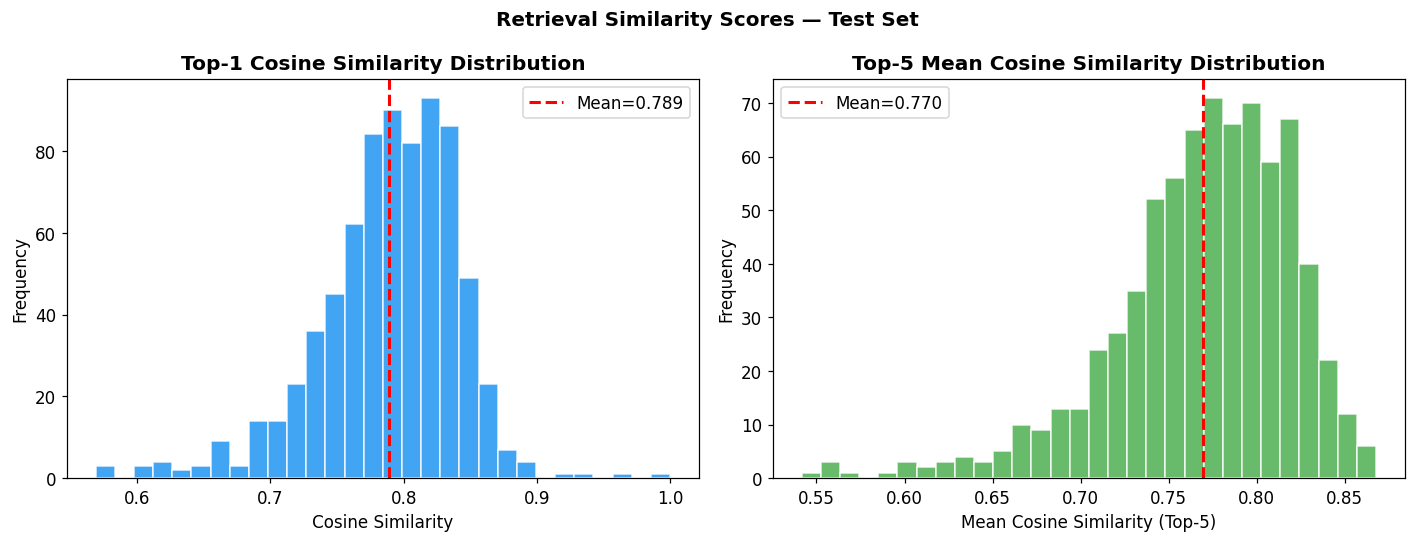

Top-1 similarity: mean=0.7893  min=0.5689  max=1.0000
Top-K mean sim  : mean=0.7696  min=0.5416  max=0.8678


In [ ]:
# ── Similarity score distribution across all test queries ────────────────────
top1_sim = all_scores[:, 0]   # top-1 cosine similarity per query
topk_sim = all_scores.mean(axis=1)  # mean over top-K per query

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(top1_sim, bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(top1_sim.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean={top1_sim.mean():.3f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Top-1 Cosine Similarity Distribution', fontweight='bold')
axes[0].legend()

axes[1].hist(topk_sim, bins=30, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].axvline(topk_sim.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean={topk_sim.mean():.3f}')
axes[1].set_xlabel(f'Mean Cosine Similarity (Top-{K})')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Top-{K} Mean Cosine Similarity Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Retrieval Similarity Scores — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Top-1 similarity: mean={top1_sim.mean():.4f}  min={top1_sim.min():.4f}  max={top1_sim.max():.4f}')
print(f'Top-K mean sim  : mean={topk_sim.mean():.4f}  min={topk_sim.min():.4f}  max={topk_sim.max():.4f}')

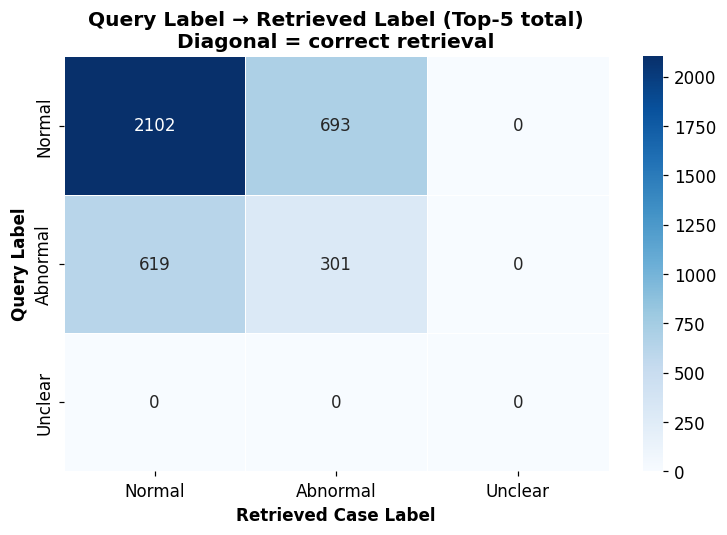

In [ ]:
# ── Similarity heatmap: query label vs retrieved label breakdown ─────────────
confusion_data = np.zeros((3, 3), dtype=int)  # [query_label, retrieved_label]

for i in range(len(test_labels)):
    q_lab = int(test_labels[i])
    for ret_idx in all_retrieved_idx[i]:
        r_lab = int(labels[ret_idx])
        confusion_data[q_lab, r_lab] += 1

label_names = ['Normal', 'Abnormal', 'Unclear']
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    confusion_data,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels = label_names,
    yticklabels = label_names,
    ax         = ax,
    linewidths = 0.5,
)
ax.set_xlabel('Retrieved Case Label',  fontweight='bold')
ax.set_ylabel('Query Label',           fontweight='bold')
ax.set_title(f'Query Label → Retrieved Label (Top-{K} total)\nDiagonal = correct retrieval',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 12 — Speed Benchmark

Verify that retrieval latency is acceptable for real-time demo.

In [ ]:
# ── Benchmark: single query latency (embedding + search) ────────────────────
N_BENCH  = 50
bench_times = []

for i in range(N_BENCH):
    test_row = df_test.iloc[i % len(df_test)]
    pil_img  = raw['test'][int(test_row['hf_index'])]['image']

    t0  = time.time()
    q_e = embed_single_image(pil_img, extractor, DEVICE)
    _   = index.search(q_e, CFG['top_k'])
    bench_times.append((time.time() - t0) * 1000)  # ms

bench_times = np.array(bench_times)
print('=== Retrieval Latency Benchmark ===')
print(f'  N queries          : {N_BENCH}')
print(f'  Mean latency       : {bench_times.mean():.1f} ms')
print(f'  Median latency     : {np.median(bench_times):.1f} ms')
print(f'  P95 latency        : {np.percentile(bench_times, 95):.1f} ms')
print(f'  Min latency        : {bench_times.min():.1f} ms')
print(f'  Max latency        : {bench_times.max():.1f} ms')
print()
if bench_times.mean() < 500:
    print('  ✓ Real-time capable (<500ms per query)')
else:
    print('  ⚠ Consider switching to IVF index for faster queries')

=== Retrieval Latency Benchmark ===
  N queries          : 50
  Mean latency       : 19.1 ms
  Median latency     : 18.4 ms
  P95 latency        : 25.3 ms
  Min latency        : 16.5 ms
  Max latency        : 31.9 ms

  ✓ Real-time capable (<500ms per query)


---
## Step 13 — Final Summary & What Notebook 6 Will Use

In [ ]:
print('='*65)
print('RAD-SCRIBE PRO — NOTEBOOK 5 COMPLETE')
print('='*65)
print()
print('What was built:')
print(f'  Backbone      : EfficientNet-B3 (frozen, ImageNet pretrained)')
print(f'  Embedding dim : {CFG["embed_dim"]} (L2-normalized)')
print(f'  Index type    : FAISS {CFG["index_type"].upper()} (cosine via inner product)')
print(f'  Index size    : {index.ntotal:,} vectors')
print(f'  Top-K         : {CFG["top_k"]}')
print()
print('Retrieval quality:')
print(f'  Top-1 Label Match Rate : {top1_acc:.1f}%')
print(f'  Top-{K} Label Recall    : {topk_recall:.1f}%')
print(f'  Mean Top-1 Cosine Sim  : {mean_sim:.4f}')
print(f'  Mean retrieval latency : {bench_times.mean():.1f} ms')
print()
print('Files saved:')
for fname, desc in [
    ('embeddings.npy',    f'({index.ntotal}, {CFG["embed_dim"]}) float32 — image features'),
    ('reports.npy',       f'({index.ntotal},) str   — aligned report texts'),
    ('indices.npy',       f'({index.ntotal},) int   — hf_index mapping'),
    ('labels.npy',        f'({index.ntotal},) int   — 0=Normal 1=Abnormal 2=Unclear'),
    ('faiss.index',       'FAISS binary index file'),
    ('retrieval_meta.json', 'build metadata'),
]:
    print(f'  {INDEX_DIR}/{fname}')
    print(f'    → {desc}')

print()
print('NEXT: Notebook 6 — 06_model_C_RAG.ipynb')
print('  Will load faiss.index + reports.npy and use them to:')
print('  1. Retrieve top-K reports for any input image')
print('  2. Build a BioGPT prompt: [retrieved context] + [generate new report]')
print('  3. Evaluate RAG vs Model A vs Model B')
print('='*65)

RAD-SCRIBE PRO — NOTEBOOK 5 COMPLETE

What was built:
  Backbone      : EfficientNet-B3 (frozen, ImageNet pretrained)
  Embedding dim : 1536 (L2-normalized)
  Index type    : FAISS FLAT (cosine via inner product)
  Index size    : 4,308 vectors
  Top-K         : 5

Retrieval quality:
  Top-1 Label Match Rate : 65.5%
  Top-5 Label Recall    : 64.7%
  Mean Top-1 Cosine Sim  : 0.7893
  Mean retrieval latency : 19.1 ms

Files saved:
  /content/drive/MyDrive/Radscribe/radscribe_index/embeddings.npy
    → (4308, 1536) float32 — image features
  /content/drive/MyDrive/Radscribe/radscribe_index/reports.npy
    → (4308,) str   — aligned report texts
  /content/drive/MyDrive/Radscribe/radscribe_index/indices.npy
    → (4308,) int   — hf_index mapping
  /content/drive/MyDrive/Radscribe/radscribe_index/labels.npy
    → (4308,) int   — 0=Normal 1=Abnormal 2=Unclear
  /content/drive/MyDrive/Radscribe/radscribe_index/faiss.index
    → FAISS binary index file
  /content/drive/MyDrive/Radscribe/radscri

In [ ]:
# ── Verify all files exist before closing notebook ───────────────────────────
required_files = [
    f'{INDEX_DIR}/embeddings.npy',
    f'{INDEX_DIR}/reports.npy',
    f'{INDEX_DIR}/indices.npy',
    f'{INDEX_DIR}/labels.npy',
    f'{INDEX_DIR}/faiss.index',
    f'{INDEX_DIR}/retrieval_meta.json',
]
all_ok = True
print('File verification:')
for fpath in required_files:
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) / 1e6 if exists else 0
    status = f'✓ ({size:.1f} MB)' if exists else '✗ MISSING'
    print(f'  {status}  {fpath}')
    if not exists:
        all_ok = False
print()
if all_ok:
    print('All files present ✓ — ready for Notebook 6 (RAG generation)')
else:
    print('WARNING: Some files are missing. Re-run cells from Step 5 onwards.')

File verification:
  ✓ (26.5 MB)  /content/drive/MyDrive/Radscribe/radscribe_index/embeddings.npy
  ✓ (1.3 MB)  /content/drive/MyDrive/Radscribe/radscribe_index/reports.npy
  ✓ (0.0 MB)  /content/drive/MyDrive/Radscribe/radscribe_index/indices.npy
  ✓ (0.0 MB)  /content/drive/MyDrive/Radscribe/radscribe_index/labels.npy
  ✓ (26.5 MB)  /content/drive/MyDrive/Radscribe/radscribe_index/faiss.index
  ✓ (0.0 MB)  /content/drive/MyDrive/Radscribe/radscribe_index/retrieval_meta.json

All files present ✓ — ready for Notebook 6 (RAG generation)
